# Les Graphes expliqués simplement
### De la carte du métro à la détection de fraude

Ce notebook ne nécessite aucune connaissance en mathématiques ou en informatique.  
Chaque concept est introduit par une analogie du quotidien, avant de voir comment l'appliquer à un réseau de paiements.

---

## Table des matières

1. [Le graphe, c'est quoi concrètement ?](#partie-1)
2. [Comment naviguer dans un réseau ?](#partie-2)
3. [Qui est important dans le réseau ?](#partie-3)
4. [Qui forme des clans ?](#partie-4)
5. [Comment une machine "voit" un réseau ?](#partie-5)
6. [Détecter ce qui est bizarre](#partie-6)
7. [Application : réseau de paiements](#partie-7)

In [11]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.ensemble import IsolationForest
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')
print("Prêt !")

Prêt !


---

# <a name="partie-1"></a> 1. Le graphe, c'est quoi concrètement ?

## L'idée de base

Un graphe, c'est simplement une façon de représenter **des choses et les liens entre elles**.

Vous en utilisez tous les jours sans le savoir :

| Ce que vous voyez | Les "choses" (nœuds) | Les "liens" (arêtes) |
|---|---|---|
| Plan du métro | Stations | Lignes |
| Réseau d'amis | Personnes | Amitiés |
| Internet | Pages web | Liens hypertextes |
| Réseau de paiements | Clients / Fournisseurs | Transactions |

En langage graphe, on appelle ces "choses" des **nœuds** et ces "liens" des **arêtes**.

---

### Exemple 1 — Un réseau d'amis (liens sans direction)

Si Alice et Bob sont amis, la relation est **symétrique** : Alice est amie avec Bob, Bob est ami avec Alice. On parle de **graphe non-dirigé**.

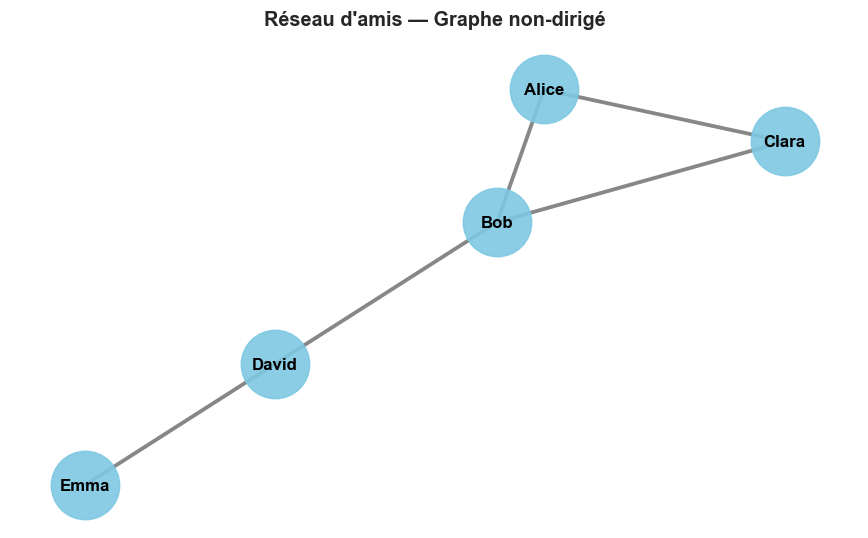

Nombre de personnes (nœuds) : 5
Nombre d'amitiés (arêtes)   : 5


In [12]:
# Réseau d'amis
G_amis = nx.Graph()
amis = ['Alice', 'Bob', 'Clara', 'David', 'Emma']
liens = [('Alice', 'Bob'), ('Alice', 'Clara'), ('Bob', 'Clara'), ('Bob', 'David'), ('David', 'Emma')]

G_amis.add_nodes_from(amis)
G_amis.add_edges_from(liens)

plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G_amis, seed=7)
nx.draw_networkx_nodes(G_amis, pos, node_size=2000, node_color='#7EC8E3', alpha=0.9)
nx.draw_networkx_labels(G_amis, pos, font_size=11, font_weight='bold')
nx.draw_networkx_edges(G_amis, pos, width=2.5, alpha=0.7, edge_color='#555555')
plt.title("Réseau d'amis — Graphe non-dirigé", fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Nombre de personnes (nœuds) : {G_amis.number_of_nodes()}")
print(f"Nombre d'amitiés (arêtes)   : {G_amis.number_of_edges()}")

### Exemple 2 — Des paiements (liens avec direction)

Un paiement n'est pas symétrique : c'est **A qui paie B**, pas l'inverse.  
On représente ça avec une flèche. On parle de **graphe dirigé**.

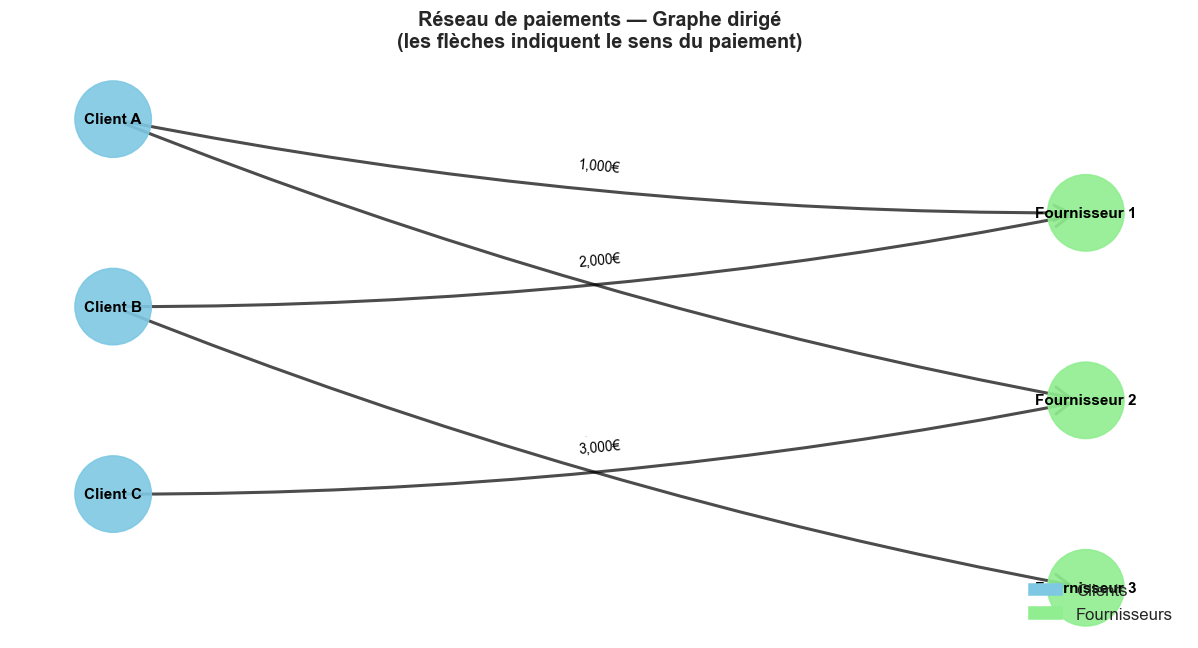

Ce qu'on voit d'un coup d'œil :
  → Fournisseur 1 reçoit de deux clients (A et B) : c'est un acteur central
  → Client C ne paie qu'un seul fournisseur : relation exclusive
  → Client A est le plus diversifié : il paie deux fournisseurs différents


In [13]:
# Réseau de paiements simple
G_paiements = nx.DiGraph()

clients = ['Client A', 'Client B', 'Client C']
fournisseurs = ['Fournisseur 1', 'Fournisseur 2', 'Fournisseur 3']

transactions = [
    ('Client A', 'Fournisseur 1', 1000),
    ('Client A', 'Fournisseur 2', 500),
    ('Client B', 'Fournisseur 1', 2000),
    ('Client B', 'Fournisseur 3', 1500),
    ('Client C', 'Fournisseur 2', 3000),
]

for src, dst, montant in transactions:
    G_paiements.add_edge(src, dst, weight=montant)

plt.figure(figsize=(11, 6))

# Positionner clients à gauche, fournisseurs à droite
pos = {}
for i, c in enumerate(clients):
    pos[c] = (-1, 1 - i)
for i, f in enumerate(fournisseurs):
    pos[f] = (1, 0.5 - i)

node_colors = ['#7EC8E3' if n in clients else '#90EE90' for n in G_paiements.nodes()]
nx.draw_networkx_nodes(G_paiements, pos, node_size=2500, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(G_paiements, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_paiements, pos, width=2, alpha=0.7, arrowsize=25,
                       connectionstyle='arc3,rad=0.05', arrowstyle='->')
edge_labels = {(u, v): f"{d['weight']:,}€" for u, v, d in G_paiements.edges(data=True)}
nx.draw_networkx_edge_labels(G_paiements, pos, edge_labels, font_size=9)

# Légende
patch_c = mpatches.Patch(color='#7EC8E3', label='Clients')
patch_f = mpatches.Patch(color='#90EE90', label='Fournisseurs')
plt.legend(handles=[patch_c, patch_f], loc='lower right', fontsize=11)

plt.title("Réseau de paiements — Graphe dirigé\n(les flèches indiquent le sens du paiement)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Ce qu'on voit d'un coup d'œil :")
print("  → Fournisseur 1 reçoit de deux clients (A et B) : c'est un acteur central")
print("  → Client C ne paie qu'un seul fournisseur : relation exclusive")
print("  → Client A est le plus diversifié : il paie deux fournisseurs différents")

### Exemple 3 — Les montants comptent aussi (graphe pondéré)

On peut ajouter une **valeur** sur chaque lien — par exemple le montant d'une transaction.  
Plus le lien est épais, plus le montant est élevé. On parle de **graphe pondéré**.

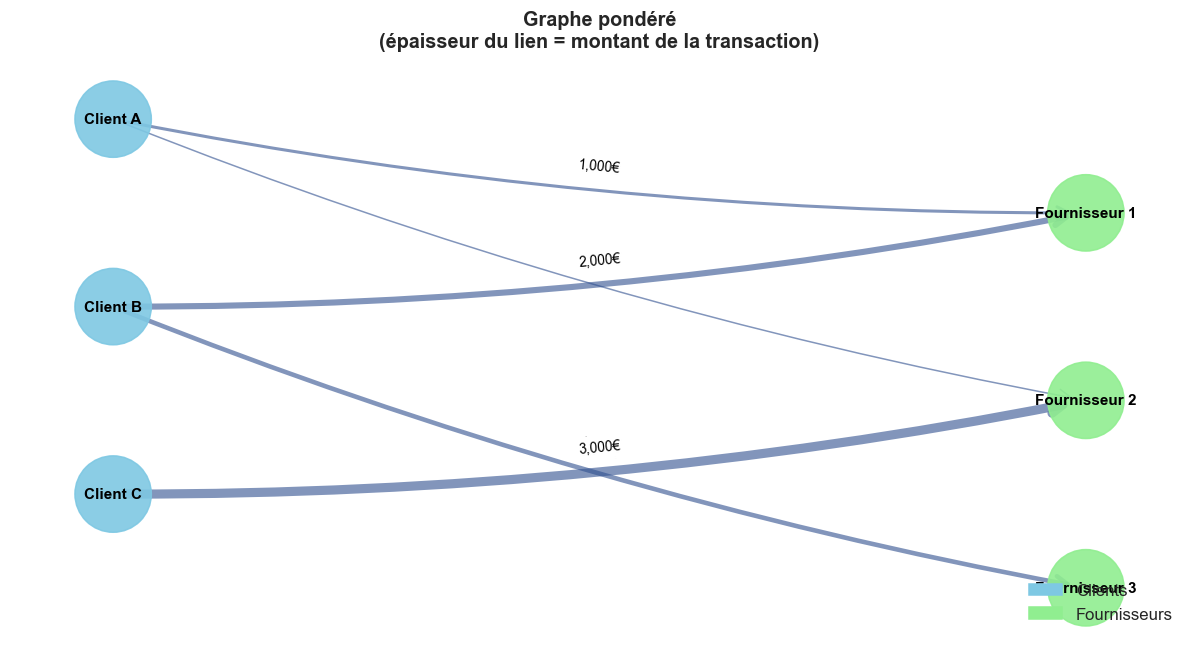

Ce que l'épaisseur révèle :
  → Client C → Fournisseur 2 (3 000€) : lien le plus épais = transaction la plus importante
  → Client A → Fournisseur 2 (500€) : lien fin = petite transaction


In [14]:
plt.figure(figsize=(11, 6))

# Épaisseur proportionnelle au montant
weights = [G_paiements[u][v]['weight'] / 500 for u, v in G_paiements.edges()]

node_colors = ['#7EC8E3' if n in clients else '#90EE90' for n in G_paiements.nodes()]
nx.draw_networkx_nodes(G_paiements, pos, node_size=2500, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(G_paiements, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_paiements, pos, width=weights, alpha=0.6, arrowsize=20,
                       connectionstyle='arc3,rad=0.05', edge_color='#2F4F8F', arrowstyle='->')
nx.draw_networkx_edge_labels(G_paiements, pos, edge_labels, font_size=9)

plt.legend(handles=[patch_c, patch_f], loc='lower right', fontsize=11)
plt.title("Graphe pondéré\n(épaisseur du lien = montant de la transaction)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Ce que l'épaisseur révèle :")
print("  → Client C → Fournisseur 2 (3 000€) : lien le plus épais = transaction la plus importante")
print("  → Client A → Fournisseur 2 (500€) : lien fin = petite transaction")

### À retenir

> **Un graphe = des nœuds + des arêtes.**  
> Les arêtes peuvent avoir une direction (paiement) et une valeur (montant).  
> La visualisation permet de voir d'un coup d'œil des patterns qu'un tableau de données cacherait.

---

# <a name="partie-2"></a> 2. Comment naviguer dans un réseau ?

## L'analogie du GPS

Quand vous utilisez Google Maps, vous lui demandez : "Comment aller de A à B le plus vite possible ?"

Dans un graphe, on pose la même question : **quel est le chemin le plus court entre deux nœuds ?**

Dans un réseau de paiements, ça répond à : *"En combien d'intermédiaires peut-on relier ce client à cet autre client ?"*

### Pourquoi c'est utile ?
- **Détecter des connexions cachées** : deux clients qui semblent indépendants mais sont reliés via 2 fournisseurs communs
- **Mesurer la proximité** dans le réseau : des acteurs proches se "connaissent" indirectement
- **Identifier des clusters isolés** : des groupes sans aucun lien entre eux

Chemin le plus court entre Alice et David :
  Alice → Bob → Clara → David (3 étapes)


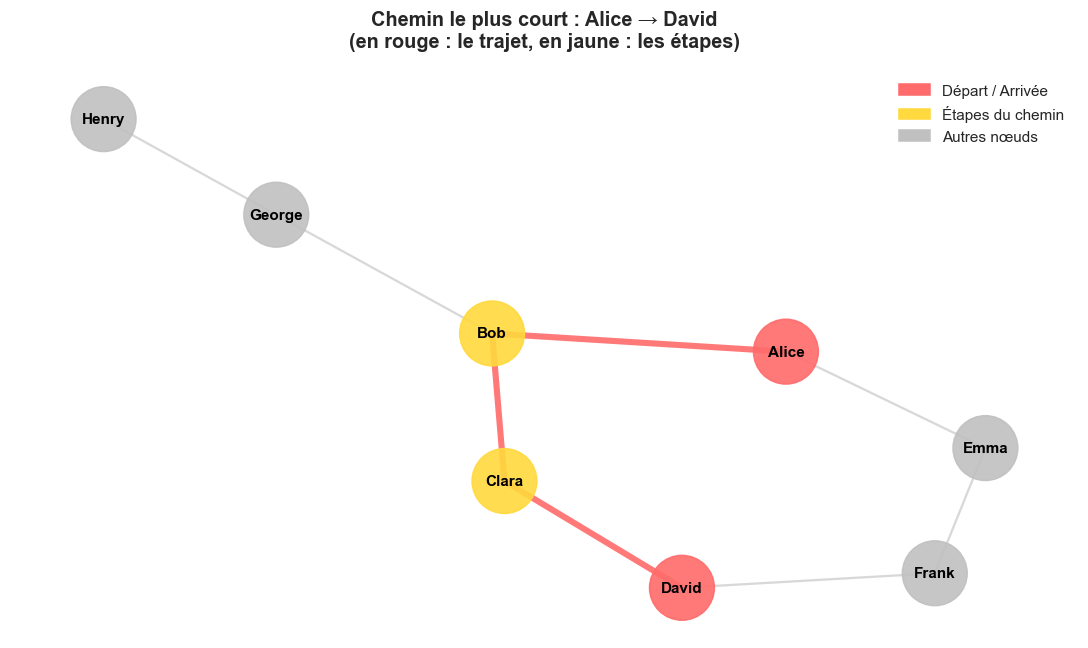

In [15]:
# Construire un réseau plus grand pour illustrer les chemins
G_nav = nx.Graph()
liens_nav = [
    ('Alice', 'Bob'), ('Bob', 'Clara'), ('Clara', 'David'),
    ('Alice', 'Emma'), ('Emma', 'Frank'), ('Frank', 'David'),
    ('Bob', 'George'), ('George', 'Henry'),
]
G_nav.add_edges_from(liens_nav)

pos_nav = nx.spring_layout(G_nav, seed=12)

# Trouver le chemin le plus court entre Alice et David
chemin = nx.shortest_path(G_nav, 'Alice', 'David')
print(f"Chemin le plus court entre Alice et David :")
print(f"  {' → '.join(chemin)} ({len(chemin)-1} étapes)")

# Visualiser
plt.figure(figsize=(10, 6))

aretes_chemin = [(chemin[i], chemin[i+1]) for i in range(len(chemin)-1)]
aretes_autres = [e for e in G_nav.edges() if e not in aretes_chemin and (e[1], e[0]) not in aretes_chemin]

couleurs_noeuds = []
for n in G_nav.nodes():
    if n == 'Alice' or n == 'David':
        couleurs_noeuds.append('#FF6B6B')
    elif n in chemin:
        couleurs_noeuds.append('#FFD93D')
    else:
        couleurs_noeuds.append('#C0C0C0')

nx.draw_networkx_nodes(G_nav, pos_nav, node_size=1800, node_color=couleurs_noeuds, alpha=0.9)
nx.draw_networkx_labels(G_nav, pos_nav, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_nav, pos_nav, edgelist=aretes_autres, width=1.5, alpha=0.3, edge_color='gray')
nx.draw_networkx_edges(G_nav, pos_nav, edgelist=aretes_chemin, width=4, alpha=0.9, edge_color='#FF6B6B')

rouge = mpatches.Patch(color='#FF6B6B', label='Départ / Arrivée')
jaune = mpatches.Patch(color='#FFD93D', label='Étapes du chemin')
gris  = mpatches.Patch(color='#C0C0C0', label='Autres nœuds')
plt.legend(handles=[rouge, jaune, gris], loc='upper right', fontsize=10)

plt.title("Chemin le plus court : Alice → David\n(en rouge : le trajet, en jaune : les étapes)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

### Composantes connexes — "Est-ce que tout le monde est connecté ?"

Parfois, un réseau est **fragmenté** : certains groupes n'ont aucun lien avec le reste.  
On appelle ces groupes isolés des **composantes connexes**.

Dans un réseau de paiements, des groupes complètement isolés peuvent indiquer :
- Des entités qui n'interagissent jamais entre elles (normal)
- Ou au contraire, des cellules organisées qui évitent tout contact avec le réseau principal (suspect)

Nombre de groupes (composantes connexes) : 4
  Groupe 1 : ['A', 'B', 'C']
  Groupe 2 : ['D', 'E', 'F']
  Groupe 3 : ['G', 'H']
  Groupe 4 : ['I']


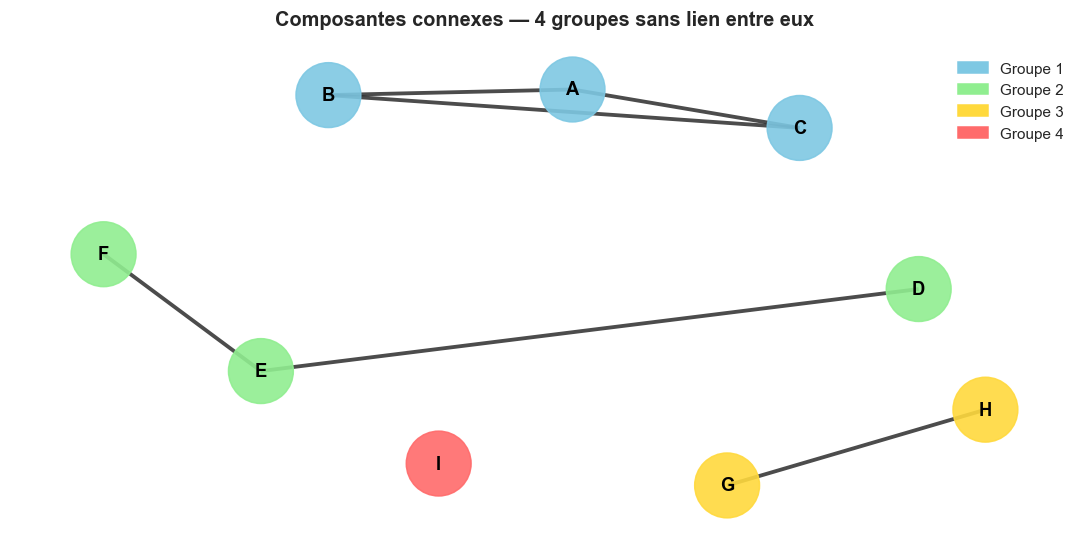

In [16]:
# Réseau avec plusieurs groupes isolés
G_comp = nx.Graph()
G_comp.add_edges_from([
    ('A', 'B'), ('B', 'C'), ('A', 'C'),          # Groupe 1
    ('D', 'E'), ('E', 'F'),                        # Groupe 2
    ('G', 'H'),                                    # Groupe 3
])
G_comp.add_node('I')                              # Groupe 4 : nœud isolé

composantes = list(nx.connected_components(G_comp))
print(f"Nombre de groupes (composantes connexes) : {len(composantes)}")
for i, comp in enumerate(composantes, 1):
    print(f"  Groupe {i} : {sorted(comp)}")

# Colorier chaque groupe différemment
couleurs_palette = ['#7EC8E3', '#90EE90', '#FFD93D', '#FF6B6B']
couleur_noeud = {}
for i, comp in enumerate(composantes):
    for n in comp:
        couleur_noeud[n] = couleurs_palette[i]

plt.figure(figsize=(10, 5))
pos_comp = nx.spring_layout(G_comp, seed=5, k=2)
colors = [couleur_noeud[n] for n in G_comp.nodes()]
nx.draw_networkx_nodes(G_comp, pos_comp, node_size=1800, node_color=colors, alpha=0.9)
nx.draw_networkx_labels(G_comp, pos_comp, font_size=12, font_weight='bold')
nx.draw_networkx_edges(G_comp, pos_comp, width=2.5, alpha=0.7)

patches = [mpatches.Patch(color=couleurs_palette[i], label=f'Groupe {i+1}') for i in range(len(composantes))]
plt.legend(handles=patches, loc='upper right', fontsize=10)
plt.title("Composantes connexes — 4 groupes sans lien entre eux",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

### À retenir

> **Naviguer dans un graphe, c'est répondre à "Qui peut atteindre qui, et en combien d'étapes ?"**  
> Les groupes isolés révèlent la structure cachée d'un réseau.

---

# <a name="partie-3"></a> 3. Qui est important dans le réseau ?

## L'idée

"Être important" dans un réseau peut vouloir dire plusieurs choses.  
Imaginez une ville :
- La gare centrale (tout le monde y passe) est importante **par son nombre de connexions**
- Un pont unique (seul moyen de passer d'un quartier à l'autre) est important **par sa position stratégique**
- La mairie (proche de tout) est importante **par sa proximité**
- Le maire (recommandé par des gens influents) est important **par sa réputation**

On a une mesure pour chaque cas.

---

### Mesure 1 — Degree : "Combien de connexions ?"
**Analogie** : popularité sur les réseaux sociaux. Plus vous avez d'amis, plus votre degré est élevé.

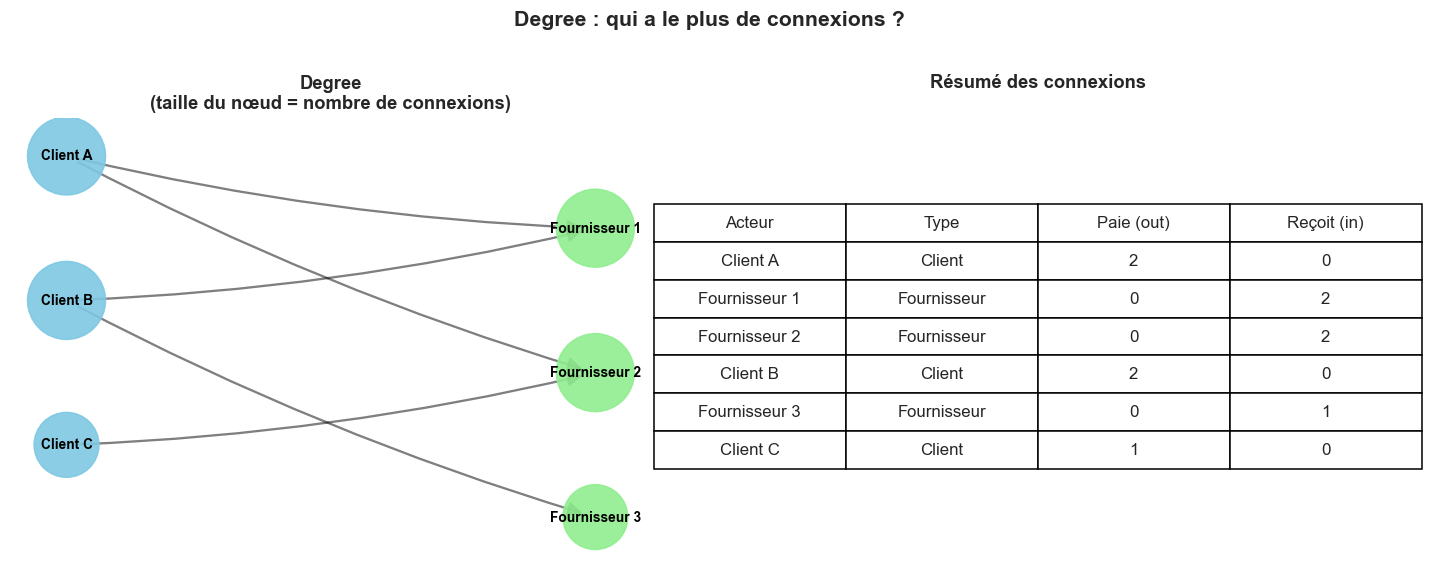

Lecture : Fournisseur 1 reçoit de 2 clients → acteur central côté fournisseurs


In [17]:
# Utiliser le réseau de paiements
G = G_paiements.copy()

# Degree : nombre de transactions reçues (in) ou envoyées (out)
in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())

df = pd.DataFrame({
    'Acteur': list(G.nodes()),
    'Type': ['Client' if n in clients else 'Fournisseur' for n in G.nodes()],
    'Paie (out)': [out_degree[n] for n in G.nodes()],
    'Reçoit (in)': [in_degree[n] for n in G.nodes()],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique réseau avec taille proportionnelle au degree total
ax = axes[0]
degree_total = {n: in_degree[n] + out_degree[n] for n in G.nodes()}
sizes = [1000 + degree_total[n] * 800 for n in G.nodes()]
colors_nodes = ['#7EC8E3' if n in clients else '#90EE90' for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors_nodes, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5, arrowsize=20,
                       connectionstyle='arc3,rad=0.05', ax=ax)
ax.set_title("Degree\n(taille du nœud = nombre de connexions)", fontweight='bold')
ax.axis('off')

# Tableau
ax2 = axes[1]
ax2.axis('off')
table_data = df.values.tolist()
table = ax2.table(cellText=table_data, colLabels=df.columns,
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
ax2.set_title("Résumé des connexions", fontweight='bold', pad=20)

plt.suptitle("Degree : qui a le plus de connexions ?", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Lecture : Fournisseur 1 reçoit de 2 clients → acteur central côté fournisseurs")

### Mesure 2 — Betweenness : "Le carrefour incontournable"

**Analogie** : Le Carrefour (le rond-point, pas le supermarché).  
Même si vous n'allez pas au carrefour, vous êtes obligé de le traverser pour aller d'un endroit à un autre.  

Un nœud avec un **betweenness élevé** est celui par lequel passent le plus de chemins dans le réseau.  
Si ce nœud disparaît, le réseau se fragmente.

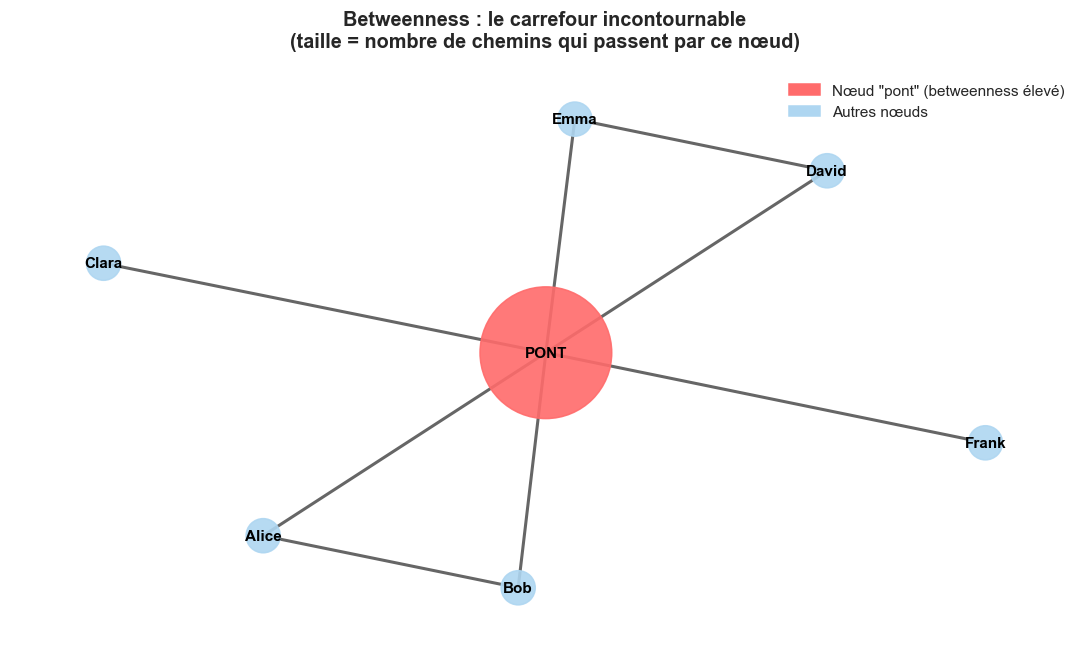

Scores de betweenness :
  PONT     : ██████████████████████████ (0.87)
  Alice    :  (0.00)
  Bob      :  (0.00)
  Clara    :  (0.00)
  David    :  (0.00)
  Emma     :  (0.00)
  Frank    :  (0.00)

Si 'PONT' disparaît, le réseau se coupe en deux parties qui ne peuvent plus communiquer.


In [18]:
# Réseau plus illustratif pour le betweenness
G_bet = nx.Graph()
G_bet.add_edges_from([
    ('Alice', 'PONT'), ('Bob', 'PONT'), ('Clara', 'PONT'),
    ('PONT', 'David'), ('PONT', 'Emma'), ('PONT', 'Frank'),
    ('Alice', 'Bob'),
    ('David', 'Emma'),
])

betweenness = nx.betweenness_centrality(G_bet)
pos_bet = nx.spring_layout(G_bet, seed=42)

plt.figure(figsize=(10, 6))
sizes = [500 + betweenness[n] * 8000 for n in G_bet.nodes()]
couleurs = ['#FF6B6B' if n == 'PONT' else '#AED6F1' for n in G_bet.nodes()]

nx.draw_networkx_nodes(G_bet, pos_bet, node_size=sizes, node_color=couleurs, alpha=0.9)
nx.draw_networkx_labels(G_bet, pos_bet, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_bet, pos_bet, width=2, alpha=0.6)

rouge = mpatches.Patch(color='#FF6B6B', label='Nœud "pont" (betweenness élevé)')
bleu  = mpatches.Patch(color='#AED6F1', label='Autres nœuds')
plt.legend(handles=[rouge, bleu], loc='upper right', fontsize=10)

plt.title("Betweenness : le carrefour incontournable\n"
          "(taille = nombre de chemins qui passent par ce nœud)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Scores de betweenness :")
for noeud, score in sorted(betweenness.items(), key=lambda x: -x[1]):
    barre = '█' * int(score * 30)
    print(f"  {noeud:8s} : {barre} ({score:.2f})")
print("\nSi 'PONT' disparaît, le réseau se coupe en deux parties qui ne peuvent plus communiquer.")

### Mesure 3 — PageRank : "La réputation par recommandation"

**Analogie** : C'est l'algorithme original de Google.  
Être recommandé par une seule célébrité vaut plus qu'être recommandé par 10 inconnus.  

Un nœud a un **PageRank élevé** s'il reçoit des liens de nœuds qui sont eux-mêmes importants.  
Dans un réseau de paiements : un fournisseur payé par de **gros clients** a un PageRank élevé.

In [19]:
pagerank = nx.pagerank(G_paiements)
betweenness_p = nx.betweenness_centrality(G_paiements)
degree_cent = nx.degree_centrality(G_paiements)

print("PageRank dans le réseau de paiements :")
print("(Plus le score est élevé, plus l'acteur est 'recommandé' par des acteurs importants)")
print()
for noeud, score in sorted(pagerank.items(), key=lambda x: -x[1]):
    barre = '█' * int(score * 60)
    type_n = 'Client      ' if noeud in clients else 'Fournisseur '
    print(f"  [{type_n}] {noeud:15s} : {barre} ({score:.3f})")

print()
print("Interprétation : Fournisseur 2 reçoit de Client A (qui paie aussi Fournisseur 1)")
print("et de Client C (qui paie le plus gros montant) → réputation élevée")

PageRank dans le réseau de paiements :
(Plus le score est élevé, plus l'acteur est 'recommandé' par des acteurs importants)

  [Fournisseur ] Fournisseur 2   : ██████████████ (0.250)
  [Fournisseur ] Fournisseur 1   : ██████████████ (0.240)
  [Fournisseur ] Fournisseur 3   : █████████ (0.160)
  [Client      ] Client A        : ███████ (0.117)
  [Client      ] Client B        : ███████ (0.117)
  [Client      ] Client C        : ███████ (0.117)

Interprétation : Fournisseur 2 reçoit de Client A (qui paie aussi Fournisseur 1)
et de Client C (qui paie le plus gros montant) → réputation élevée


### Tableau récapitulatif des 4 mesures d'importance

| Mesure | Analogie | Question posée | Signal d'alerte |
|---|---|---|---|
| **Degree** | Popularité | Combien de connexions ? | Client qui multiplie soudainement les fournisseurs |
| **Betweenness** | Carrefour | Qui est incontournable ? | Intermédiaire qui connecte des groupes normalement séparés |
| **Closeness** | Proximité | Qui est au centre ? | Nouveau tiers qui devient très central très vite |
| **PageRank** | Réputation | Qui est recommandé par les importants ? | Gros paiement vers un tiers peu réputé |

---

# <a name="partie-4"></a> 4. Qui forme des clans ?

## L'analogie du lycée

Dans un lycée, les élèves forment naturellement des groupes : les sportifs, les geeks, les artistes...  
Ces groupes se créent **sans qu'on le décide** — ils émergent des affinités naturelles.

Un graphe fait pareil. On peut demander à l'algorithme : **"Trouve les groupes naturels dans ce réseau."**  
C'est ce qu'on appelle la **détection de communautés**.

### Pourquoi c'est crucial pour la fraude ?

Un **anneau de fraude** est un groupe de comptes qui transactionnent ensemble de façon coordonnée,  
mais sont présentés comme des entités indépendantes.  
La détection de communautés peut révéler ces structures cachées.

Communautés détectées automatiquement : 3
  Communauté 1 : ['C1', 'C2', 'C3', 'F1', 'F2']
  Communauté 2 : ['C4', 'C5', 'F3', 'F4']
  Communauté 3 : ['C6', 'C7', 'C8', 'F5']


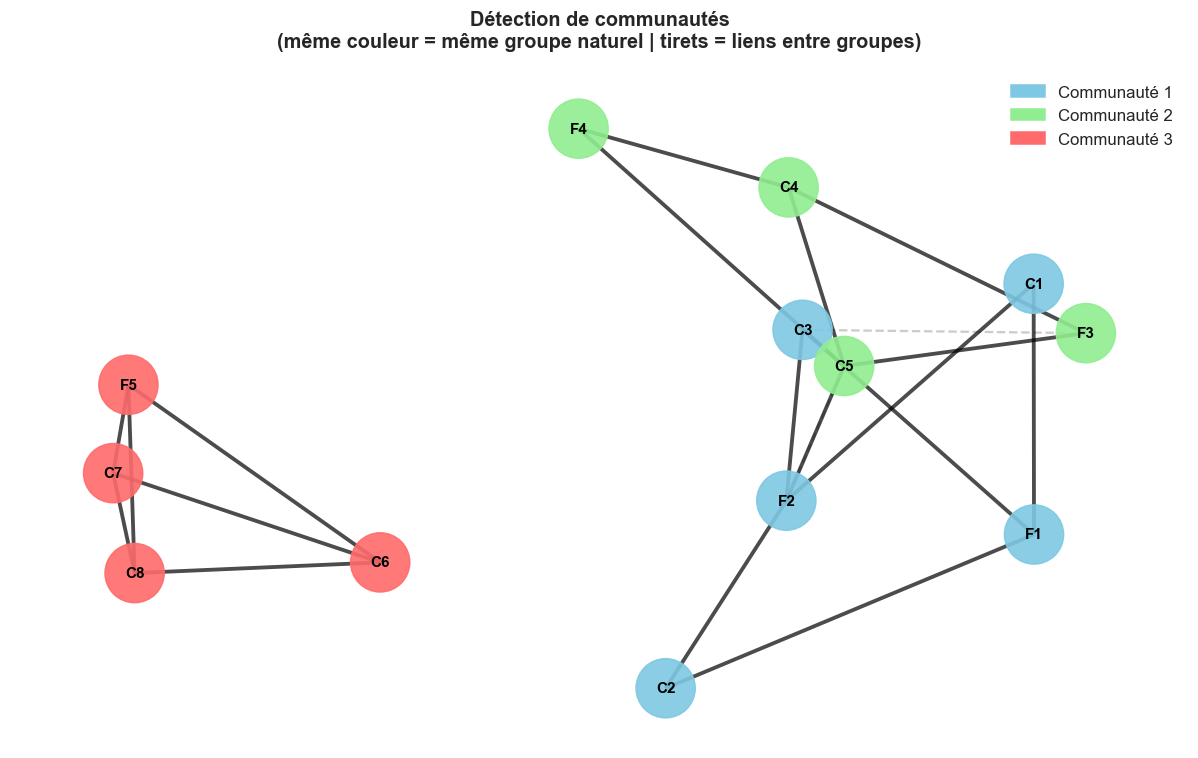

In [29]:
# Réseau avec des communautés naturelles
#np.random.seed(42)

# Groupe 1 : transactions légitimes classiques
G_com = nx.Graph()
groupe1 = ['C1', 'C2', 'C3', 'F1', 'F2']
groupe2 = ['C4', 'C5', 'F3', 'F4']
groupe3 = ['C6', 'C7', 'C8', 'F5']  # cluster suspect

# Liens intra-groupe (denses)
liens_g1 = [('C1','F1'), ('C2','F1'), ('C1','F2'), ('C3','F2'), ('C2','F2'), ('C3','F1')]
liens_g2 = [('C4','F3'), ('C5','F3'), ('C4','F4'), ('C5','F4'), ('C4','C5')]
liens_g3 = [('C6','F5'), ('C7','F5'), ('C8','F5'), ('C6','C7'), ('C7','C8'), ('C6','C8')]

# Quelques liens inter-groupe (rares)
liens_inter = [('C3','F3'), ('C5','F2')]

G_com.add_edges_from(liens_g1 + liens_g2 + liens_g3 + liens_inter)

# Détection de communautés (algorithme de Louvain simplifié via greedy)
from networkx.algorithms.community import greedy_modularity_communities
communautes = list(greedy_modularity_communities(G_com))

print(f"Communautés détectées automatiquement : {len(communautes)}")
for i, com in enumerate(communautes, 1):
    print(f"  Communauté {i} : {sorted(com)}")

# Colorier par communauté
palette = ['#7EC8E3', '#90EE90', '#FF6B6B', '#FFD93D']
couleur_map = {}
for i, com in enumerate(communautes):
    for n in com:
        couleur_map[n] = palette[i % len(palette)]

pos_com = nx.spring_layout(G_com, seed=8, k=1.5)
plt.figure(figsize=(11, 7))

node_colors_com = [couleur_map[n] for n in G_com.nodes()]
nx.draw_networkx_nodes(G_com, pos_com, node_size=1500, node_color=node_colors_com, alpha=0.9)
nx.draw_networkx_labels(G_com, pos_com, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_com, pos_com, edgelist=liens_inter, width=1.5,
                       alpha=0.4, edge_color='gray', style='dashed')
nx.draw_networkx_edges(G_com, pos_com,
                       edgelist=[e for e in G_com.edges() if e not in liens_inter],
                       width=2.5, alpha=0.7)

patches = [mpatches.Patch(color=palette[i], label=f'Communauté {i+1}') for i in range(len(communautes))]
plt.legend(handles=patches, loc='upper right', fontsize=11)
plt.title("Détection de communautés\n"
          "(même couleur = même groupe naturel | tirets = liens entre groupes)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

### Application fraude : détecter un anneau de transactions coordonnées

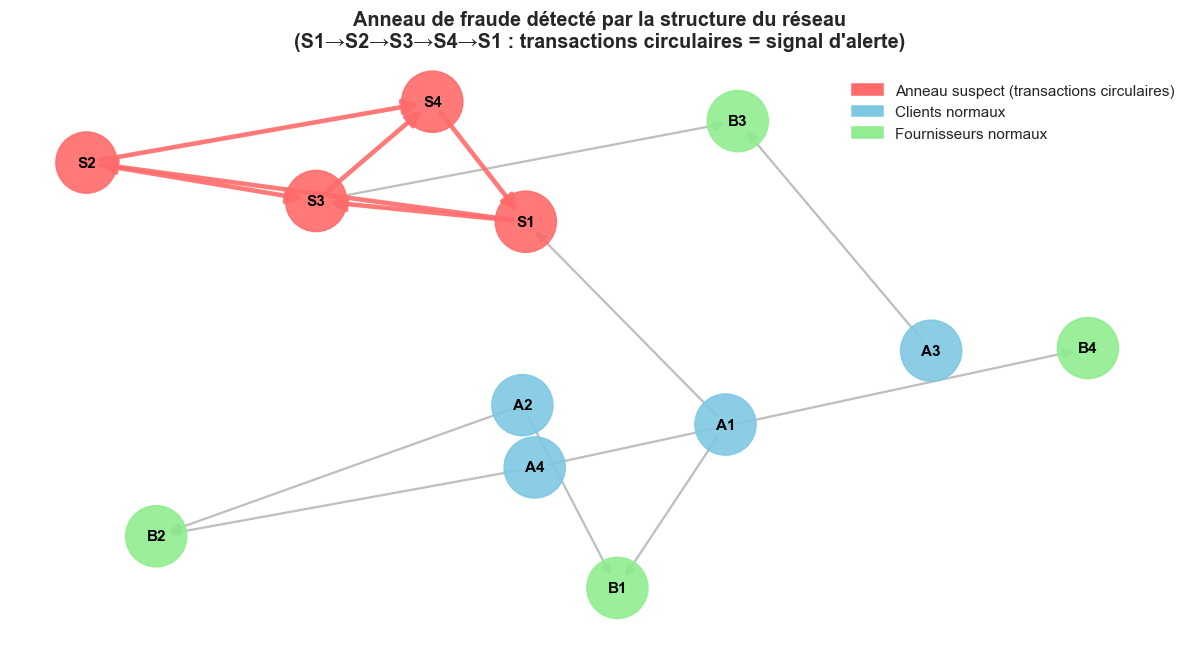

Signal d'alerte : dans un réseau de paiements légitimes,
les clients paient des fournisseurs — pas d'autres clients.
Des transactions circulaires entre entités = structure anormale.


In [21]:
# Simuler un réseau normal + un groupe suspect très dense
G_fraude = nx.DiGraph()

# Transactions normales (peu denses)
normaux = [('A1','B1'), ('A2','B1'), ('A2','B2'), ('A3','B3'), ('A4','B2'), ('A4','B4')]

# Anneau de fraude : tout le monde paie tout le monde (circulaire)
suspects = ['S1', 'S2', 'S3', 'S4']
anneau = [('S1','S2'), ('S2','S3'), ('S3','S4'), ('S4','S1'),
          ('S1','S3'), ('S2','S4')]  # + liens croisés

# Quelques liens entre l'anneau et le réseau normal (pour se fondre)
camouflage = [('A1','S1'), ('S3','B3')]

G_fraude.add_edges_from(normaux + anneau + camouflage)

pos_f = nx.spring_layout(G_fraude, seed=99, k=1.2)
plt.figure(figsize=(11, 6))

couleurs_f = []
for n in G_fraude.nodes():
    if n in suspects:
        couleurs_f.append('#FF6B6B')
    elif n.startswith('A'):
        couleurs_f.append('#7EC8E3')
    else:
        couleurs_f.append('#90EE90')

nx.draw_networkx_nodes(G_fraude, pos_f, node_size=1600, node_color=couleurs_f, alpha=0.9)
nx.draw_networkx_labels(G_fraude, pos_f, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G_fraude, pos_f, edgelist=normaux + camouflage,
                       width=1.5, alpha=0.5, arrowsize=15, edge_color='gray')
nx.draw_networkx_edges(G_fraude, pos_f, edgelist=anneau,
                       width=3, alpha=0.9, arrowsize=20, edge_color='#FF6B6B')

rouge = mpatches.Patch(color='#FF6B6B', label='Anneau suspect (transactions circulaires)')
bleu  = mpatches.Patch(color='#7EC8E3', label='Clients normaux')
vert  = mpatches.Patch(color='#90EE90', label='Fournisseurs normaux')
plt.legend(handles=[rouge, bleu, vert], loc='upper right', fontsize=10)

plt.title("Anneau de fraude détecté par la structure du réseau\n"
          "(S1→S2→S3→S4→S1 : transactions circulaires = signal d'alerte)",
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Signal d'alerte : dans un réseau de paiements légitimes,")
print("les clients paient des fournisseurs — pas d'autres clients.")
print("Des transactions circulaires entre entités = structure anormale.")

### À retenir

> **Les communautés émergent naturellement dans tout réseau.**  
> Un groupe anormalement dense, ou des transactions circulaires, peuvent trahir une coordination frauduleuse.

---

# <a name="partie-5"></a> 5. Comment une machine "voit" un réseau ?

## Le problème

Une machine ne peut pas "voir" un dessin de graphe.  
Elle ne comprend que des **chiffres**.

Alors comment lui transmettre l'information "ce client est central dans le réseau" ?  
On transforme chaque nœud en une **fiche descriptive numérique**.

**Analogie** : Pour comparer des joueurs de football, on ne leur demande pas de jouer devant un jury.  
On remplit une fiche : buts, passes, distance parcourue, pourcentage de tirs...  
Ces chiffres résument le joueur. C'est un **embedding**.

### La fiche d'un nœud dans notre réseau

In [22]:
# Créer les fiches descriptives pour chaque acteur
G_emb = G_paiements

deg_cent   = nx.degree_centrality(G_emb)
between    = nx.betweenness_centrality(G_emb)
close      = nx.closeness_centrality(G_emb)
pr         = nx.pagerank(G_emb)
in_deg     = dict(G_emb.in_degree())
out_deg    = dict(G_emb.out_degree())

fiches = []
for noeud in G_emb.nodes():
    fiches.append({
        'Acteur':         noeud,
        'Type':           'Client' if noeud in clients else 'Fournisseur',
        'Nb paiements envoyés':  out_deg[noeud],
        'Nb paiements reçus':    in_deg[noeud],
        'Centralité':     round(deg_cent[noeud], 3),
        'Position pont':  round(between[noeud], 3),
        'Proximité':      round(close[noeud], 3),
        'Réputation':     round(pr[noeud], 3),
    })

df_fiches = pd.DataFrame(fiches)
print("Fiche descriptive de chaque acteur (son 'embedding') :")
print()
print(df_fiches.to_string(index=False))

print()
print("Lecture : Client A envoie 2 paiements, ne reçoit rien (il est client).")
print("         Sa réputation (PageRank) est de 0.117 — comparable aux autres clients.")

Fiche descriptive de chaque acteur (son 'embedding') :

       Acteur        Type  Nb paiements envoyés  Nb paiements reçus  Centralité  Position pont  Proximité  Réputation
     Client A      Client                     2                   0         0.4            0.0        0.0       0.117
Fournisseur 1 Fournisseur                     0                   2         0.4            0.0        0.4       0.240
Fournisseur 2 Fournisseur                     0                   2         0.4            0.0        0.4       0.250
     Client B      Client                     2                   0         0.4            0.0        0.0       0.117
Fournisseur 3 Fournisseur                     0                   1         0.2            0.0        0.2       0.160
     Client C      Client                     1                   0         0.2            0.0        0.0       0.117

Lecture : Client A envoie 2 paiements, ne reçoit rien (il est client).
         Sa réputation (PageRank) est de 0.117

### "Ces deux acteurs se ressemblent-ils ?"

Une fois qu'on a les fiches, on peut mesurer à quel point deux acteurs se **ressemblent dans le réseau**.  

**Analogie** : Deux joueurs avec des fiches très similaires jouent dans le même style.  
Si l'un est transféré dans l'équipe adverse, ça paraît bizarre.

En paiements : si un client paie soudainement un fournisseur dont le profil est très différent du sien → signal d'alerte.

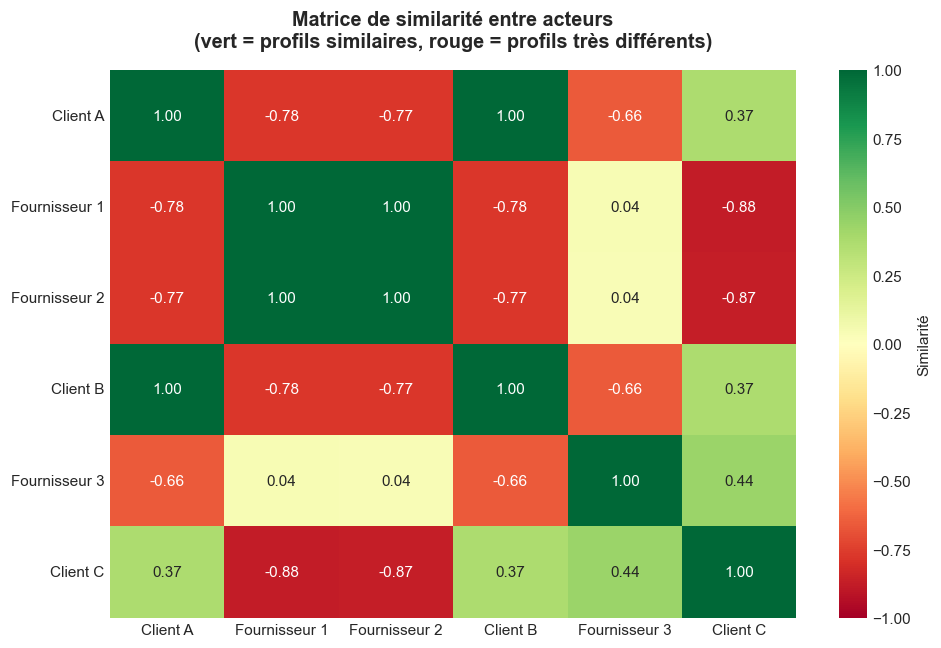

Lecture :
  → Les 3 clients se ressemblent entre eux (même profil : ils envoient des paiements)
  → Les fournisseurs se ressemblent entre eux (même profil : ils reçoivent)
  → Un client et un fournisseur ont des profils opposés (rouge)

Signal d'alerte : si Client A paie Fournisseur Z et que leurs profils
sont encore plus différents que la normale, c'est suspect.


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

features = df_fiches[['Nb paiements envoyés', 'Nb paiements reçus',
                        'Centralité', 'Position pont', 'Proximité', 'Réputation']].values
features_scaled = StandardScaler().fit_transform(features)
sim_matrix = cosine_similarity(features_scaled)

noms = df_fiches['Acteur'].tolist()
df_sim = pd.DataFrame(sim_matrix, index=noms, columns=noms)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(df_sim, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Similarité'})
ax.set_title("Matrice de similarité entre acteurs\n"
             "(vert = profils similaires, rouge = profils très différents)",
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("Lecture :")
print("  → Les 3 clients se ressemblent entre eux (même profil : ils envoient des paiements)")
print("  → Les fournisseurs se ressemblent entre eux (même profil : ils reçoivent)")
print("  → Un client et un fournisseur ont des profils opposés (rouge)")
print()
print("Signal d'alerte : si Client A paie Fournisseur Z et que leurs profils")
print("sont encore plus différents que la normale, c'est suspect.")

### À retenir

> **Transformer un graphe en chiffres, c'est créer une fiche descriptive pour chaque acteur.**  
> On peut ensuite comparer les acteurs entre eux et détecter ceux qui "ne vont pas ensemble".

---

# <a name="partie-6"></a> 6. Détecter ce qui est bizarre

## L'analogie du mouton noir

Imaginez un troupeau de 1000 moutons blancs et un mouton noir.  
Pour identifier le mouton noir, il suffit de poser une seule question : "Quelle est ta couleur ?"  

Pour identifier un mouton blanc parmi d'autres moutons blancs, il faudrait poser beaucoup de questions.  

**Isolation Forest** exploite exactement cette idée :
- **Un point anormal** = facile à isoler, peu de questions nécessaires
- **Un point normal** = difficile à isoler, beaucoup de questions nécessaires

"Isoler" veut dire : séparer ce point de tous les autres par des coupures successives.

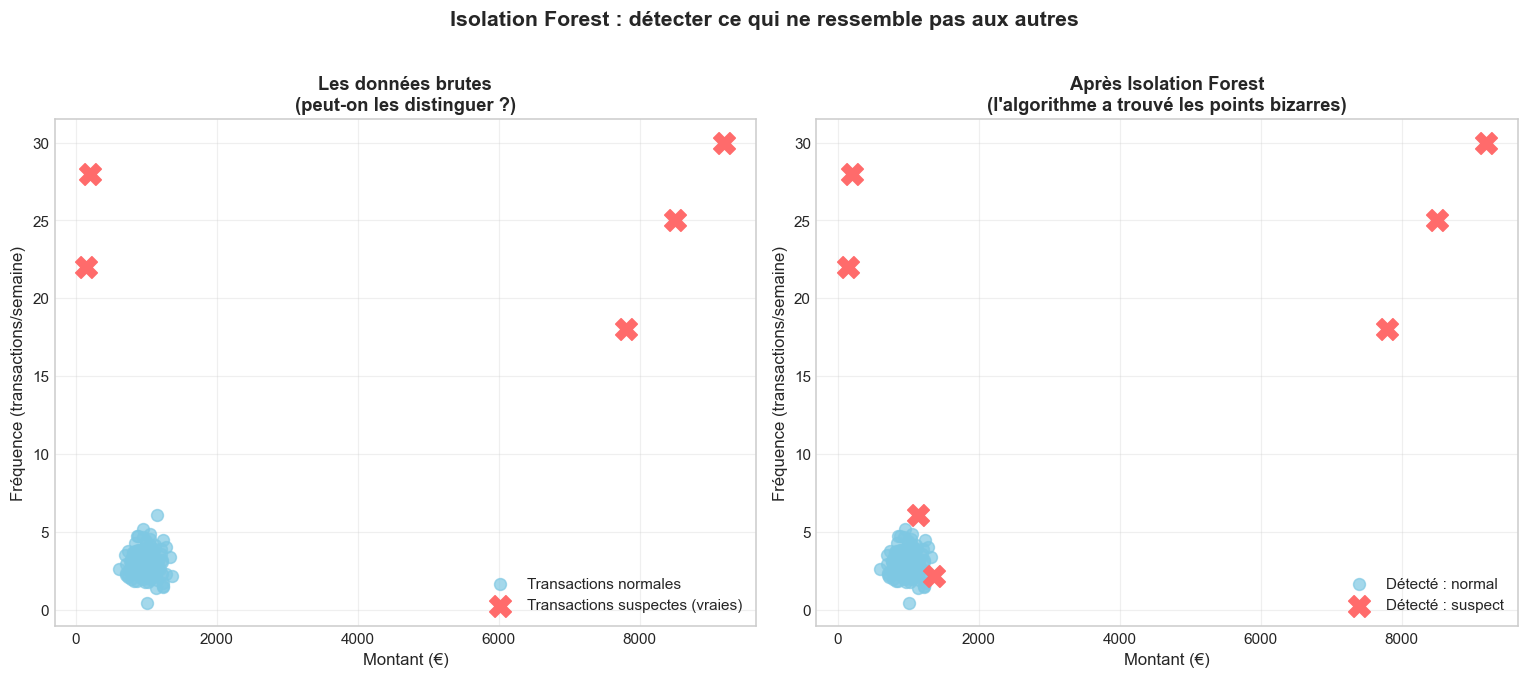

Résultat : 7 transactions détectées comme suspectes sur 155 au total
Ce sont les points 'faciles à isoler' — ceux qui ne ressemblent à aucun autre.


In [24]:
# Simuler des données de transactions
np.random.seed(42)

# Transactions normales : montant ~1000€, fréquence ~3/semaine
n_normal = 150
montants_normaux   = np.random.normal(1000, 150, n_normal)
frequences_normales = np.random.normal(3, 0.8, n_normal)

# Transactions suspectes
montants_suspects   = [8500, 9200, 200, 150, 7800]
frequences_suspectes = [25,   30,   28,  22,  18]

X_normal = np.column_stack([montants_normaux, frequences_normales])
X_suspect = np.column_stack([montants_suspects, frequences_suspectes])
X = np.vstack([X_normal, X_suspect])
labels_vrais = ['Normal'] * n_normal + ['Suspect'] * len(montants_suspects)

# Appliquer Isolation Forest
iso = IsolationForest(contamination=0.04, random_state=42)
predictions = iso.fit_predict(X)
scores = -iso.score_samples(X)

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : les données brutes
ax1 = axes[0]
ax1.scatter(montants_normaux, frequences_normales, c='#7EC8E3', s=60, alpha=0.7, label='Transactions normales')
ax1.scatter(montants_suspects, frequences_suspectes, c='#FF6B6B', s=200, marker='X',
            zorder=5, label='Transactions suspectes (vraies)')
ax1.set_xlabel('Montant (€)', fontsize=11)
ax1.set_ylabel('Fréquence (transactions/semaine)', fontsize=11)
ax1.set_title('Les données brutes\n(peut-on les distinguer ?)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Graphique 2 : après Isolation Forest
ax2 = axes[1]
normaux_pred  = X[predictions == 1]
suspects_pred = X[predictions == -1]
ax2.scatter(normaux_pred[:,0],  normaux_pred[:,1],  c='#7EC8E3', s=60, alpha=0.7, label='Détecté : normal')
ax2.scatter(suspects_pred[:,0], suspects_pred[:,1], c='#FF6B6B', s=200, marker='X',
            zorder=5, label='Détecté : suspect')
ax2.set_xlabel('Montant (€)', fontsize=11)
ax2.set_ylabel('Fréquence (transactions/semaine)', fontsize=11)
ax2.set_title("Après Isolation Forest\n(l'algorithme a trouvé les points bizarres)",
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle("Isolation Forest : détecter ce qui ne ressemble pas aux autres",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_detectes = (predictions == -1).sum()
print(f"Résultat : {n_detectes} transactions détectées comme suspectes sur {len(X)} au total")
print("Ce sont les points 'faciles à isoler' — ceux qui ne ressemblent à aucun autre.")

### Le score d'anomalie — "À quel point c'est bizarre ?"

Au lieu d'un simple oui/non, Isolation Forest donne un **score**.  
Plus le score est élevé, plus la transaction est difficile à expliquer.

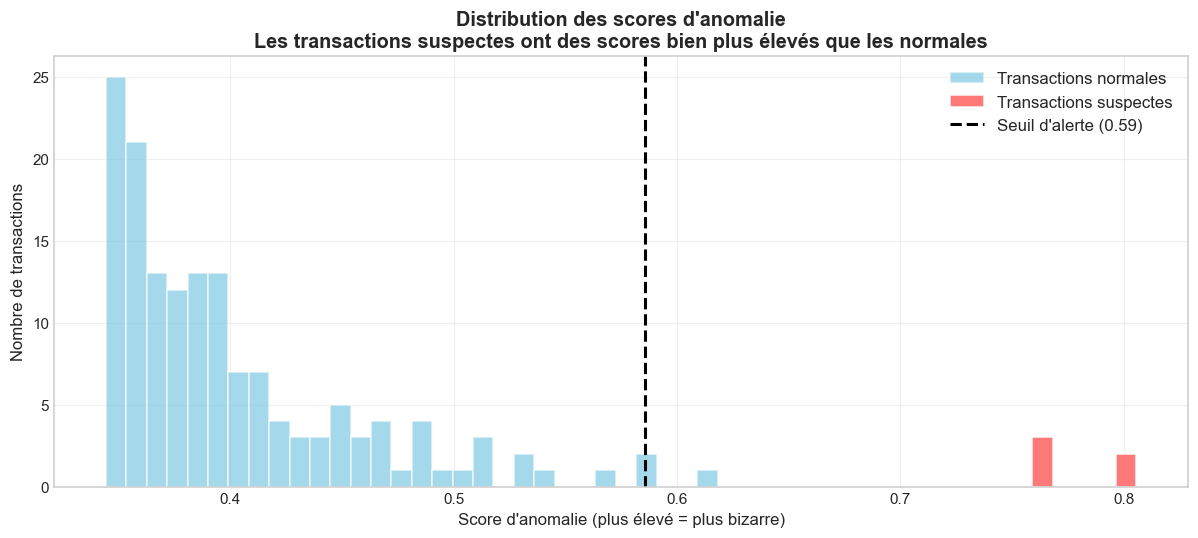

En pratique : on définit un seuil (ex: top 4% des scores)
Toute transaction au-dessus déclenche une revue manuelle.


In [25]:
fig, ax = plt.subplots(figsize=(11, 5))

scores_normaux  = scores[:n_normal]
scores_suspects = scores[n_normal:]

ax.hist(scores_normaux, bins=30, alpha=0.7, color='#7EC8E3', label='Transactions normales', edgecolor='white')
ax.hist(scores_suspects, bins=5, alpha=0.9, color='#FF6B6B', label='Transactions suspectes', edgecolor='white')

seuil = np.percentile(scores, 96)
ax.axvline(seuil, color='black', linestyle='--', linewidth=2, label=f'Seuil d\'alerte ({seuil:.2f})')

ax.set_xlabel('Score d\'anomalie (plus élevé = plus bizarre)', fontsize=11)
ax.set_ylabel('Nombre de transactions', fontsize=11)
ax.set_title("Distribution des scores d'anomalie\n"
             "Les transactions suspectes ont des scores bien plus élevés que les normales",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("En pratique : on définit un seuil (ex: top 4% des scores)")
print("Toute transaction au-dessus déclenche une revue manuelle.")

### À retenir

> **Isolation Forest cherche ce qui est facile à isoler = ce qui ne ressemble à rien d'autre.**  
> Il produit un score : plus le score est élevé, plus la transaction mérite investigation.

---

# <a name="partie-7"></a> 7. Application : réseau de paiements

## On met tout ensemble

Voici comment les 6 étapes précédentes s'enchaînent dans la vraie vie :

```
Transactions
    ↓
Graphe (Part. 1)
    ↓
Groupes & chemins (Part. 2-4)
    ↓
Fiches numériques (Part. 5)
    ↓
Score d'anomalie (Part. 6)
    ↓
Explication des signaux d'alerte
```

---

### Les 6 signaux d'alerte

Une fois le score calculé, on cherche **pourquoi** la transaction est suspecte.  
On a identifié 6 signaux :

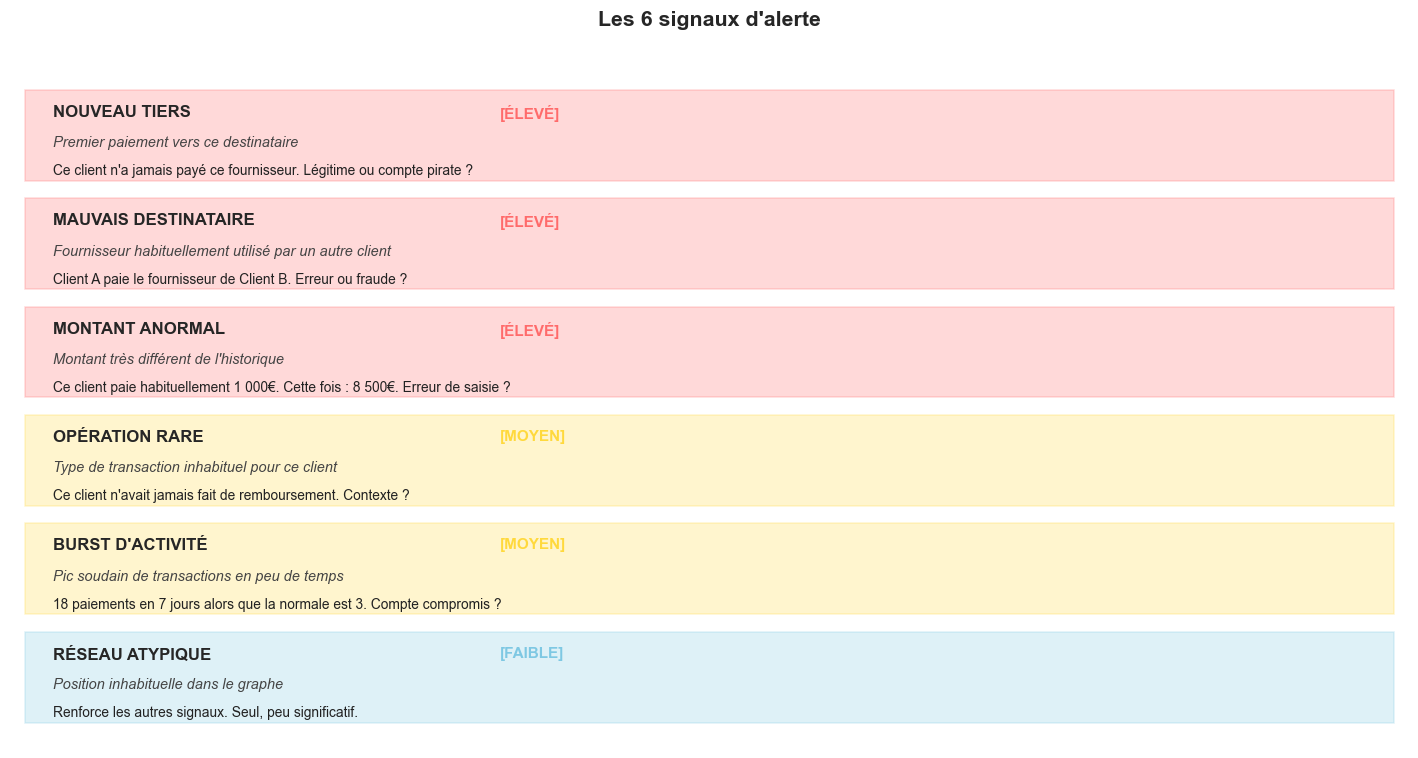

In [26]:
signaux = [
    ('NOUVEAU TIERS',        'ÉLEVÉ',  'Premier paiement vers ce destinataire',
     'Ce client n\'a jamais payé ce fournisseur. Légitime ou compte pirate ?'),
    ('MAUVAIS DESTINATAIRE', 'ÉLEVÉ',  'Fournisseur habituellement utilisé par un autre client',
     'Client A paie le fournisseur de Client B. Erreur ou fraude ?'),
    ('MONTANT ANORMAL',      'ÉLEVÉ',  'Montant très différent de l\'historique',
     'Ce client paie habituellement 1 000€. Cette fois : 8 500€. Erreur de saisie ?'),
    ('OPÉRATION RARE',       'MOYEN',  'Type de transaction inhabituel pour ce client',
     'Ce client n\'avait jamais fait de remboursement. Contexte ?'),
    ('BURST D\'ACTIVITÉ',    'MOYEN',  'Pic soudain de transactions en peu de temps',
     '18 paiements en 7 jours alors que la normale est 3. Compte compromis ?'),
    ('RÉSEAU ATYPIQUE',      'FAIBLE', 'Position inhabituelle dans le graphe',
     'Renforce les autres signaux. Seul, peu significatif.'),
]

couleurs_niveaux = {'ÉLEVÉ': '#FF6B6B', 'MOYEN': '#FFD93D', 'FAIBLE': '#7EC8E3'}

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')

y = 0.95
for signal, niveau, desc_courte, explication in signaux:
    couleur = couleurs_niveaux[niveau]
    ax.add_patch(plt.Rectangle((0.01, y-0.14), 0.98, 0.13, transform=ax.transAxes,
                                color=couleur, alpha=0.25, zorder=0))
    ax.text(0.03, y-0.03, f"{signal}", transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.35, y-0.03, f"[{niveau}]", transform=ax.transAxes,
            fontsize=10, fontweight='bold', color=couleur, va='top')
    ax.text(0.03, y-0.075, desc_courte, transform=ax.transAxes,
            fontsize=9.5, va='top', style='italic', color='#444444')
    ax.text(0.03, y-0.115, explication, transform=ax.transAxes,
            fontsize=9, va='top', color='#222222')
    y -= 0.155

ax.set_title("Les 6 signaux d'alerte", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Cas pratique : investigation d'une alerte

Le système remonte une alerte. Voici ce qu'on voit :

In [27]:
# Alerte reçue
alerte = {
    'transaction_id': 'TXN-99821',
    'date':           '2024-11-14',
    'client':         'Client A',
    'fournisseur':    'Fournisseur Z',
    'montant':        25000,
    'type':           'Remboursement',
    'score_anomalie': 0.78,
}

contexte = {
    'historique_montant_moyen': 1200,
    'nb_transactions_precedentes_fournisseur': 0,
    'fournisseur_connu_autres_clients': True,
    'nb_transactions_7_derniers_jours': 3,
    'type_operation_utilise_avant': False,
}

print("=" * 65)
print(f"  RAPPORT D'ALERTE — {alerte['transaction_id']}")
print("=" * 65)
print(f"  Date        : {alerte['date']}")
print(f"  Client      : {alerte['client']}")
print(f"  Fournisseur : {alerte['fournisseur']}")
print(f"  Montant     : {alerte['montant']:,}€  ({alerte['type']})")
print(f"  Score       : {alerte['score_anomalie']} / 1.00  (top 1% le plus suspect)")
print()
print("  SIGNAUX DÉTECTÉS")
print("-" * 65)

signaux_detectes = []

if contexte['nb_transactions_precedentes_fournisseur'] == 0:
    print("  🔴 NOUVEAU TIERS [ÉLEVÉ]")
    print(f"     Jamais payé Fournisseur Z auparavant")
    signaux_detectes.append('ÉLEVÉ')

if contexte['fournisseur_connu_autres_clients']:
    print("  🔴 MAUVAIS DESTINATAIRE [ÉLEVÉ]")
    print(f"     Fournisseur Z est utilisé par d'autres clients — pas par Client A")
    signaux_detectes.append('ÉLEVÉ')

ratio = alerte['montant'] / contexte['historique_montant_moyen']
if ratio > 5:
    print(f"  🔴 MONTANT ANORMAL [ÉLEVÉ]")
    print(f"     {alerte['montant']:,}€ vs moyenne habituelle {contexte['historique_montant_moyen']:,}€ ({ratio:.0f}x plus élevé)")
    signaux_detectes.append('ÉLEVÉ')

if not contexte['type_operation_utilise_avant']:
    print(f"  🟡 OPÉRATION RARE [MOYEN]")
    print(f"     '{alerte['type']}' jamais utilisé par Client A")
    signaux_detectes.append('MOYEN')

n_eleve = signaux_detectes.count('ÉLEVÉ')
n_moyen = signaux_detectes.count('MOYEN')

print()
print("=" * 65)
if n_eleve >= 2:
    print("  RECOMMANDATION : BLOQUER ET INVESTIGUER EN URGENCE")
    print(f"  {n_eleve} signaux ÉLEVÉS détectés simultanément")
elif n_eleve == 1:
    print("  RECOMMANDATION : Investigation recommandée")
print("=" * 65)
print()
print("  ACTIONS SUGGÉRÉES")
print("  1. Vérifier si Fournisseur Z est dans la base fournisseurs validés")
print("  2. Contacter Client A pour confirmer la transaction")
print("  3. Vérifier les documents (facture, bon de commande)")
print("  4. Si fraude confirmée → bloquer et escalader")
print("  5. Si légitime → valider et mettre à jour le profil")

  RAPPORT D'ALERTE — TXN-99821
  Date        : 2024-11-14
  Client      : Client A
  Fournisseur : Fournisseur Z
  Montant     : 25,000€  (Remboursement)
  Score       : 0.78 / 1.00  (top 1% le plus suspect)

  SIGNAUX DÉTECTÉS
-----------------------------------------------------------------
  🔴 NOUVEAU TIERS [ÉLEVÉ]
     Jamais payé Fournisseur Z auparavant
  🔴 MAUVAIS DESTINATAIRE [ÉLEVÉ]
     Fournisseur Z est utilisé par d'autres clients — pas par Client A
  🔴 MONTANT ANORMAL [ÉLEVÉ]
     25,000€ vs moyenne habituelle 1,200€ (21x plus élevé)
  🟡 OPÉRATION RARE [MOYEN]
     'Remboursement' jamais utilisé par Client A

  RECOMMANDATION : BLOQUER ET INVESTIGUER EN URGENCE
  3 signaux ÉLEVÉS détectés simultanément

  ACTIONS SUGGÉRÉES
  1. Vérifier si Fournisseur Z est dans la base fournisseurs validés
  2. Contacter Client A pour confirmer la transaction
  3. Vérifier les documents (facture, bon de commande)
  4. Si fraude confirmée → bloquer et escalader
  5. Si légitime → valider e

---

## Ce qu'on a appris dans ce notebook

| Partie | Concept | Ce que ça permet |
|---|---|---|
| 1 | Graphes (nœuds, arêtes, direction, poids) | Représenter les relations entre acteurs |
| 2 | Navigation, chemins, composantes connexes | Trouver des connexions cachées |
| 3 | Centralité (degree, betweenness, PageRank) | Identifier les acteurs importants |
| 4 | Détection de communautés | Repérer des groupes coordonnés |
| 5 | Embeddings (fiches numériques) | Transformer le graphe en données machine |
| 6 | Isolation Forest | Scorer automatiquement les anomalies |
| 7 | Signaux d'alerte | Expliquer pourquoi une transaction est suspecte |

---

> **L'idée clé** : un tableau de transactions est plat.  
> Un graphe révèle la **structure** — qui est connecté à qui, comment, et à quelle intensité.  
> C'est cette structure qui rend visible ce qui serait invisible ligne par ligne.